<a href="https://colab.research.google.com/github/true-cpu/ThucHanhDeepLearning/blob/main/Buoi2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Bước chuẩn bị: Tải và làm sạch dữ liệu

Trước khi đi vào các bài tập cụ thể, chúng ta cần thực hiện tải dữ liệu và tiền xử lý cơ bản cho cả hai tập dữ liệu.

In [26]:
import pandas as pd
import numpy as np

# 1. Tập dữ liệu Bệnh tim (Heart Disease)
print("Đang xử lý dữ liệu Heart Disease...")
df_heart = pd.read_csv('/content/heart_disease_dataset.csv')
# Làm sạch: Loại bỏ các hàng có giá trị thiếu
df_cleaned = df_heart.dropna().copy()
print(f"Kích thước df_cleaned: {df_cleaned.shape}")

# 2. Tập dữ liệu Titanic
print("\nĐang xử lý dữ liệu Titanic...")
df_titanic_raw = pd.read_csv('/content/titanic_disaster.csv')

# Làm sạch Titanic:
# - Điền giá trị thiếu cho Age (trung vị) và Embarked (yếu vị)
# - Loại bỏ các cột không cần thiết cho mô hình
df_titanic_cleaned = df_titanic_raw.copy()
df_titanic_cleaned['Age'] = df_titanic_cleaned['Age'].fillna(df_titanic_cleaned['Age'].median())
df_titanic_cleaned['Embarked'] = df_titanic_cleaned['Embarked'].fillna(df_titanic_cleaned['Embarked'].mode()[0])
df_titanic_cleaned = df_titanic_cleaned.drop(['Cabin', 'PassengerId', 'Name', 'Ticket'], axis=1)

print(f"Kích thước df_titanic_cleaned: {df_titanic_cleaned.shape}")
display(df_titanic_cleaned.head())

Đang xử lý dữ liệu Heart Disease...
Kích thước df_cleaned: (284, 14)

Đang xử lý dữ liệu Titanic...
Kích thước df_titanic_cleaned: (891, 8)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


---

## Bài 1: Dự đoán Huyết áp tâm thu lúc nghỉ (trestbps) trên tập dữ liệu bệnh tim bằng mô hình Hồi quy (Regression Model)

Trong phần này, chúng ta sẽ xây dựng một mô hình hồi quy để dự đoán giá trị `trestbps` (huyết áp tâm thu lúc nghỉ) dựa trên các đặc trưng khác trong tập dữ liệu bệnh tim đã được làm sạch (`df_cleaned`).

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

print("### 1. Tải và làm sạch dữ liệu (đã được thực hiện ở trên, sử dụng df_cleaned)")
# df_cleaned đã có sẵn từ các bước trước.

print("### 2. Xác định mục tiêu và tạo bảng tương quan")
# Mục tiêu của mô hình: Dự đoán 'trestbps' (huyết áp tâm thu lúc nghỉ).
# Xác định biến mục tiêu (y_reg) và các biến đặc trưng (X_reg)
y_reg = df_cleaned['trestbps']
X_reg = df_cleaned.drop(['trestbps', 'state'], axis=1) # Loại bỏ 'trestbps' (biến mục tiêu) và 'state' (biến mục tiêu cũ không liên quan)

# Tính toán và hiển thị bảng tương quan giữa các đặc trưng số và biến mục tiêu
# Lưu ý: Chỉ tính tương quan cho các cột số. Các cột phân loại cần được mã hóa trước nếu muốn tính tương quan
df_temp_corr = X_reg.select_dtypes(include=np.number).copy()
df_temp_corr['trestbps'] = y_reg
print("\nBảng tương quan của các đặc trưng số với 'trestbps':")
correlations = df_temp_corr.corr()['trestbps'].sort_values(ascending=False)
display(correlations)

# Loại bỏ các đặc trưng số có tương quan thấp
print("\n### 2.1. Lọc đặc trưng dựa trên tương quan")
correlation_threshold = 0.1 # Ngưỡng tương quan (ví dụ: 0.1)

# Lọc các đặc trưng số dựa trên ngưỡng
# Loại bỏ 'trestbps' khỏi danh sách nếu nó có trong index của correlations
filtered_correlations = correlations[abs(correlations) > correlation_threshold].drop('trestbps', errors='ignore')
selected_numerical_features = filtered_correlations.index.tolist()

print(f"Các đặc trưng số được chọn sau khi lọc tương quan (ngưỡng > {correlation_threshold}):")
print(selected_numerical_features)

# Lấy các đặc trưng phân loại ban đầu trước khi thay đổi X_reg
categorical_features_reg = X_reg.select_dtypes(include='object').columns.tolist()

# Cập nhật X_reg chỉ với các đặc trưng số được chọn và các đặc trưng phân loại ban đầu
X_reg = X_reg[selected_numerical_features + categorical_features_reg]
print(f"Kích thước X_reg sau khi lọc đặc trưng: {X_reg.shape}")

print("\n### 3. Chia tập dữ liệu thành tập huấn luyện và tập kiểm tra")
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Kích thước tập huấn luyện X_reg: {X_train_reg.shape}")
print(f"Kích thước tập kiểm tra X_reg: {X_test_reg.shape}")
print(f"Kích thước tập huấn luyện y_reg: {y_train_reg.shape}")
print(f"Kích thước tập kiểm tra y_reg: {y_test_reg.shape}")

print("\n### 4. Chuẩn hóa dữ liệu (StandardScaler) và mã hóa One-Hot (OneHotEncoder)")
# CẬP NHẬT LẠI numerical_features_reg sau khi X_reg đã được lọc
numerical_features_reg = X_reg.select_dtypes(include=np.number).columns.tolist()
# categorical_features_reg đã được xác định ở trên

# Tạo bộ tiền xử lý (preprocessor) cho các biến số và phân loại
preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_reg),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_reg)
    ])

# Chuẩn hóa biến mục tiêu y_reg (thực hành tốt cho SGDRegressor, yêu cầu biến mục tiêu cũng được scale)
y_scaler_reg = StandardScaler()
y_train_reg_scaled = y_scaler_reg.fit_transform(y_train_reg.values.reshape(-1, 1))
y_test_reg_scaled = y_scaler_reg.transform(y_test_reg.values.reshape(-1, 1))

# Áp dụng tiền xử lý cho các đặc trưng X_reg
X_train_reg_processed = preprocessor_reg.fit_transform(X_train_reg) # fit_transform trên tập huấn luyện
X_test_reg_processed = preprocessor_reg.transform(X_test_reg) # transform trên tập kiểm tra

print("Đã hoàn thành tiền xử lý dữ liệu đặc trưng và biến mục tiêu.")
print(f"Kích thước X_train_reg_processed: {X_train_reg_processed.shape}")
print(f"Kích thước X_test_reg_processed: {X_test_reg_processed.shape}")

print("--- Dữ liệu Model 1 (X_train_reg_processed) ---")
# Feature names cần được cập nhật dựa trên các cột được chọn
all_feature_names = numerical_features_reg + preprocessor_reg.named_transformers_['cat'].get_feature_names_out(categorical_features_reg).tolist()
df_reg_preview = pd.DataFrame(X_train_reg_processed, columns=all_feature_names)
display(df_reg_preview.head())

### 1. Tải và làm sạch dữ liệu (đã được thực hiện ở trên, sử dụng df_cleaned)
### 2. Xác định mục tiêu và tạo bảng tương quan

Bảng tương quan của các đặc trưng số với 'trestbps':


,trestbps
trestbps,1.000000
age,0.271315
oldpeak,0.214182
restecg,0.173028
slope,0.141173
thal,0.137399
chol,0.131090
ca,0.091663
exang,0.050526
thalach,-0.068318



### 2.1. Lọc đặc trưng dựa trên tương quan
Các đặc trưng số được chọn sau khi lọc tương quan (ngưỡng > 0.1):
['age', 'oldpeak', 'restecg', 'slope', 'thal', 'chol']
Kích thước X_reg sau khi lọc đặc trưng: (284, 9)

### 3. Chia tập dữ liệu thành tập huấn luyện và tập kiểm tra
Kích thước tập huấn luyện X_reg: (227, 9)
Kích thước tập kiểm tra X_reg: (57, 9)
Kích thước tập huấn luyện y_reg: (227,)
Kích thước tập kiểm tra y_reg: (57,)

### 4. Chuẩn hóa dữ liệu (StandardScaler) và mã hóa One-Hot (OneHotEncoder)
Đã hoàn thành tiền xử lý dữ liệu đặc trưng và biến mục tiêu.
Kích thước X_train_reg_processed: (227, 14)
Kích thước X_test_reg_processed: (57, 14)
--- Dữ liệu Model 1 (X_train_reg_processed) ---


,age,oldpeak,restecg,slope,thal,chol,sex_F,sex_M,cp_aap,cp_asp,cp_nap,cp_tap,fbs_no,fbs_yes
0,0.731334,-0.919719,-1.006674,-1.006543,1.138356,-0.847821,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1.284711,1.240321,-1.006674,2.189055,-0.872592,-0.406674,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,1.284711,-0.587405,1.006674,0.591256,-0.872592,1.051031,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
3,1.395386,0.409537,1.006674,0.591256,1.138356,6.076277,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,-0.818119,-0.919719,-1.006674,-1.006543,-0.872592,-0.080608,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


In [28]:
print("### 5. Huấn luyện mô hình hồi quy (SGDRegressor) và đánh giá")
reg_model = SGDRegressor(max_iter=1000, tol=1e-3, eta0=0.01, random_state=42)

# Huấn luyện mô hình
print("Đang huấn luyện mô hình SGDRegressor...")
reg_model.fit(X_train_reg_processed, y_train_reg_scaled.ravel())
print("Huấn luyện hoàn tất.")

# Dự đoán trên tập kiểm tra (trên dữ liệu đã scaled)
y_pred_reg_scaled = reg_model.predict(X_test_reg_processed)

# Đảo ngược scale cho các dự đoán để đánh giá trên thang đo gốc của 'trestbps'
y_pred_reg = y_scaler_reg.inverse_transform(y_pred_reg_scaled.reshape(-1, 1))

# Đánh giá mô hình bằng các chỉ số hồi quy
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"\nMean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")

### 5. Huấn luyện mô hình hồi quy (SGDRegressor) và đánh giá
Đang huấn luyện mô hình SGDRegressor...
Huấn luyện hoàn tất.

Mean Squared Error (MSE): 240.40
Root Mean Squared Error (RMSE): 15.50
Mean Absolute Error (MAE): 12.25
R-squared (R2): 0.09


### 6. Trực quan hóa kết quả Mô hình 1 (Hồi quy trestbps)

Để đánh giá mô hình hồi quy, chúng ta sẽ vẽ biểu đồ phân tán giữa giá trị thực tế và giá trị dự đoán, cùng với đường chéo lý tưởng ($y = x$).

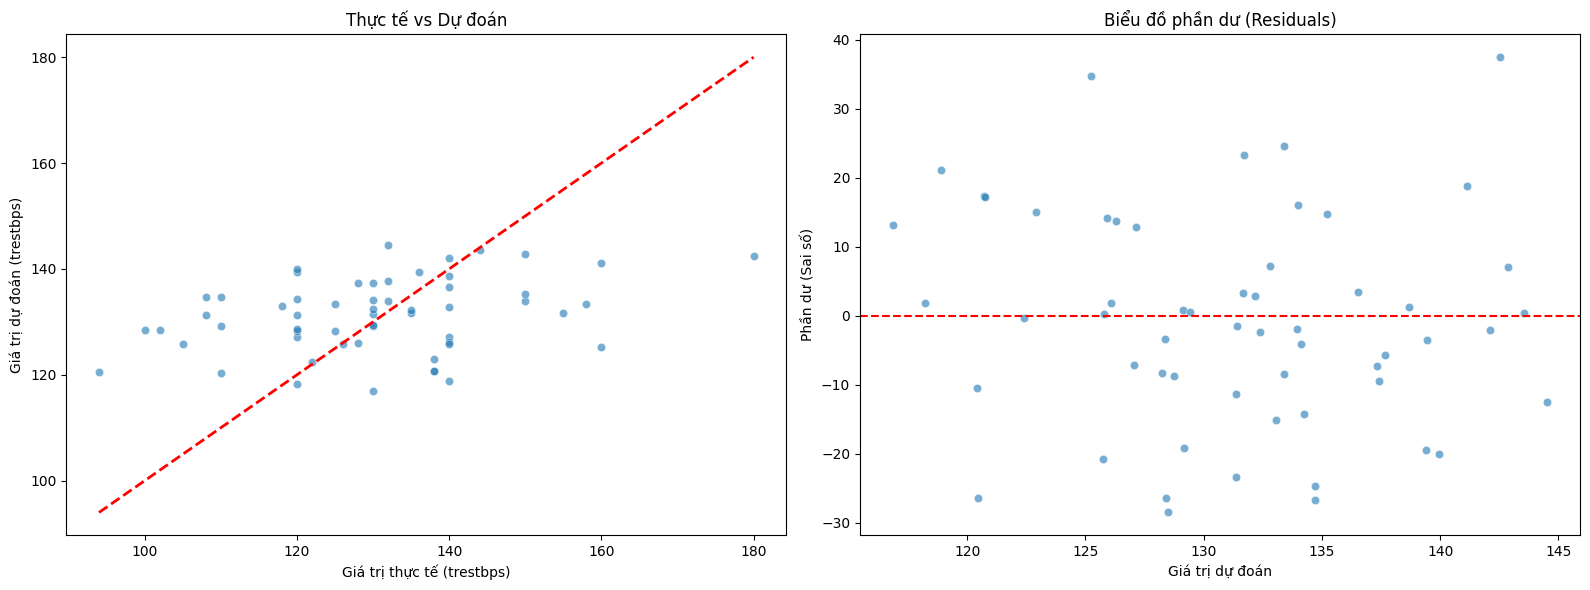

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tạo figure với 2 biểu đồ con
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Biểu đồ Thực tế vs Dự đoán
sns.scatterplot(x=y_test_reg.values, y=y_pred_reg.flatten(), ax=ax1, alpha=0.6)
ax1.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
ax1.set_xlabel('Giá trị thực tế (trestbps)')
ax1.set_ylabel('Giá trị dự đoán (trestbps)')
ax1.set_title('Thực tế vs Dự đoán')

# 2. Biểu đồ phần dư (Residual Plot)
residuals = y_test_reg.values - y_pred_reg.flatten()
sns.scatterplot(x=y_pred_reg.flatten(), y=residuals, ax=ax2, alpha=0.6)
ax2.axhline(y=0, color='r', linestyle='--')
ax2.set_xlabel('Giá trị dự đoán')
ax2.set_ylabel('Phần dư (Sai số)')
ax2.set_title('Biểu đồ phần dư (Residuals)')

plt.tight_layout()
plt.show()

---

## Bài 2: Dự đoán tỉ lệ sống sót trên Titanic bằng Mạng Nơ-ron Nhân tạo (Artificial Neural Network - ANN)

Trong phần này, chúng ta sẽ xây dựng một mô hình ANN để dự đoán khả năng sống sót (`Survived`) của hành khách trên tàu Titanic, sử dụng tập dữ liệu đã được làm sạch (`df_titanic_cleaned`).

In [30]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("### 1. Tải và làm sạch dữ liệu (đã được thực hiện ở trên, sử dụng df_titanic_cleaned)")
# df_titanic_cleaned đã có sẵn từ các bước trước.

print("### 2. Xác định mục tiêu và tạo bảng tương quan")
# Mục tiêu của mô hình: Dự đoán 'Survived' (khả năng sống sót).
# Xác định biến mục tiêu (y_ann) và các biến đặc trưng (X_ann)
y_ann = df_titanic_cleaned['Survived']
X_ann = df_titanic_cleaned.drop('Survived', axis=1)

# Tính toán và hiển thị bảng tương quan giữa các đặc trưng số và biến mục tiêu
# Thêm biến mục tiêu vào DataFrame tạm thời để tính tương quan
df_temp_corr_titanic = X_ann.select_dtypes(include=np.number).copy()
df_temp_corr_titanic['Survived'] = y_ann
print("\nBảng tương quan của các đặc trưng số với 'Survived':")
correlations_ann = df_temp_corr_titanic.corr()['Survived'].sort_values(ascending=False)
display(correlations_ann)

# Loại bỏ các đặc trưng số có tương quan thấp
print("\n### 2.1. Lọc đặc trưng dựa trên tương quan")
correlation_threshold_ann = 0.1 # Ngưỡng tương quan (ví dụ: 0.1)

# Lọc các đặc trưng số dựa trên ngưỡng
# Loại bỏ 'Survived' khỏi danh sách nếu nó có trong index của correlations_ann
filtered_correlations_ann = correlations_ann[abs(correlations_ann) > correlation_threshold_ann].drop('Survived', errors='ignore')
selected_numerical_features_ann = filtered_correlations_ann.index.tolist()

print(f"Các đặc trưng số được chọn sau khi lọc tương quan (ngưỡng > {correlation_threshold_ann}):")
print(selected_numerical_features_ann)

# Lấy các đặc trưng phân loại ban đầu trước khi thay đổi X_ann
categorical_features_ann_original = X_ann.select_dtypes(include='object').columns.tolist()

# Cập nhật X_ann chỉ với các đặc trưng số được chọn và các đặc trưng phân loại ban đầu
X_ann = X_ann[selected_numerical_features_ann + categorical_features_ann_original]
print(f"Kích thước X_ann sau khi lọc đặc trưng: {X_ann.shape}")


print("\n### 3. Chia tập dữ liệu thành tập huấn luyện và tập kiểm tra")
X_train_ann, X_test_ann, y_ann_train, y_ann_test = train_test_split(
    X_ann, y_ann, test_size=0.2, random_state=42, stratify=y_ann
)

print(f"Kích thước tập huấn luyện X_ann: {X_train_ann.shape}")
print(f"Kích thước tập kiểm tra X_ann: {X_test_ann.shape}")
print(f"Kích thước tập huấn luyện y_ann: {y_ann_train.shape}")
print(f"Kích thước tập kiểm tra y_ann: {y_ann_test.shape}")

print("\n### 4. Chuẩn hóa dữ liệu (StandardScaler) và mã hóa One-Hot (OneHotEncoder)")
# Xác định các cột phân loại và số cho X_ann sau khi lọc
numerical_features_ann = X_ann.select_dtypes(include=np.number).columns.tolist()
categorical_features_ann = X_ann.select_dtypes(include='object').columns.tolist()

# Tạo bộ tiền xử lý (preprocessor) cho các biến số và phân loại
preprocessor_ann = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_ann),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_ann)
    ])

# Áp dụng tiền xử lý cho các đặc trưng X_ann
X_train_ann_processed = preprocessor_ann.fit_transform(X_train_ann) # fit_transform trên tập huấn luyện
X_test_ann_processed = preprocessor_ann.transform(X_test_ann) # transform trên tập kiểm tra

print("Đã hoàn thành tiền xử lý dữ liệu đặc trưng.")
print(f"Kích thước X_train_ann_processed: {X_train_ann_processed.shape}")
print(f"Kích thước X_test_ann_processed: {X_test_ann_processed.shape}")

print("\n--- Dữ liệu Model 2 (X_train_ann_processed) ---")
feature_names_ann = numerical_features_ann + preprocessor_ann.named_transformers_['cat'].get_feature_names_out(categorical_features_ann).tolist()
df_ann_preview = pd.DataFrame(X_train_ann_processed, columns=feature_names_ann)
display(df_ann_preview.head())

### 1. Tải và làm sạch dữ liệu (đã được thực hiện ở trên, sử dụng df_titanic_cleaned)
### 2. Xác định mục tiêu và tạo bảng tương quan

Bảng tương quan của các đặc trưng số với 'Survived':


,Survived
Survived,1.000000
Fare,0.257307
Parch,0.081629
SibSp,-0.035322
Age,-0.064910
Pclass,-0.338481



### 2.1. Lọc đặc trưng dựa trên tương quan
Các đặc trưng số được chọn sau khi lọc tương quan (ngưỡng > 0.1):
['Fare', 'Pclass']
Kích thước X_ann sau khi lọc đặc trưng: (891, 4)

### 3. Chia tập dữ liệu thành tập huấn luyện và tập kiểm tra
Kích thước tập huấn luyện X_ann: (712, 4)
Kích thước tập kiểm tra X_ann: (179, 4)
Kích thước tập huấn luyện y_ann: (712,)
Kích thước tập kiểm tra y_ann: (179,)

### 4. Chuẩn hóa dữ liệu (StandardScaler) và mã hóa One-Hot (OneHotEncoder)
Đã hoàn thành tiền xử lý dữ liệu đặc trưng.
Kích thước X_train_ann_processed: (712, 7)
Kích thước X_test_ann_processed: (179, 7)

--- Dữ liệu Model 2 (X_train_ann_processed) ---


,Fare,Pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0.513812,0.829568,0.0,1.0,0.0,0.0,1.0
1,-0.662563,-0.370945,0.0,1.0,0.0,0.0,1.0
2,3.955399,-1.571457,0.0,1.0,0.0,0.0,1.0
3,-0.467874,0.829568,1.0,0.0,0.0,0.0,1.0
4,-0.115977,-0.370945,1.0,0.0,0.0,0.0,1.0


### 5. Xây dựng và huấn luyện mô hình ANN (sử dụng Gradient Descent)
Đang huấn luyện mô hình ANN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Huấn luyện hoàn tất.

Độ chính xác của mô hình ANN trên tập kiểm tra: 0.7933
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Báo cáo phân loại (ANN - Titanic):
               precision    recall  f1-score   support

           0       0.77      0.94      0.85       110
           1       0.85      0.57      0.68        69

    accuracy                           0.79       179
   macro avg       0.81      0.75      0.76       179
weighted avg       0.80      0.79      0.78       179



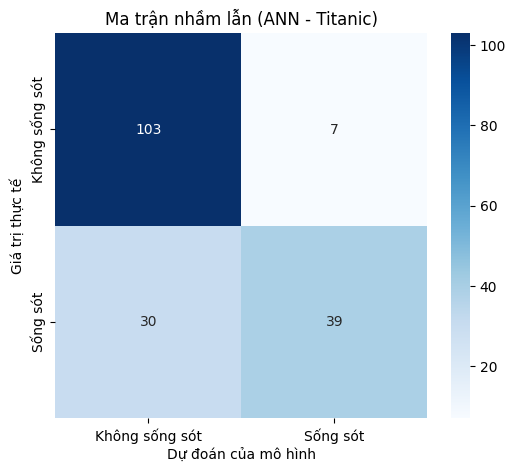

In [25]:
print("### 5. Xây dựng và huấn luyện mô hình ANN (sử dụng Gradient Descent)")
# Xác định số lượng đặc trưng đầu vào sau tiền xử lý
input_shape = X_train_ann_processed.shape[1]

# Xây dựng mô hình ANN
model_ann = Sequential([
    Dense(64, activation='relu', input_shape=(input_shape,)), # Lớp ẩn đầu tiên
    Dense(32, activation='relu'), # Lớp ẩn thứ hai
    Dense(1, activation='sigmoid') # Lớp đầu ra cho phân loại nhị phân (sống sót/không sống sót)
])

# Biên dịch mô hình (sử dụng Adam optimizer - một biến thể tối ưu của Gradient Descent)
# loss='binary_crossentropy' cho bài toán phân loại nhị phân
model_ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Huấn luyện mô hình
print("Đang huấn luyện mô hình ANN...")
history = model_ann.fit(X_train_ann_processed, y_train_ann,
                        epochs=50, batch_size=32, validation_split=0.2, verbose=0) # epochs: số lần lặp qua toàn bộ dữ liệu, batch_size: số mẫu mỗi lần cập nhật trọng số
print("Huấn luyện hoàn tất.")

# Đánh giá mô hình trên tập kiểm tra
loss, accuracy = model_ann.evaluate(X_test_ann_processed, y_test_ann, verbose=0)
print(f"\nĐộ chính xác của mô hình ANN trên tập kiểm tra: {accuracy:.4f}")

# Dự đoán trên tập kiểm tra
y_pred_ann_prob = model_ann.predict(X_test_ann_processed)
y_pred_ann = (y_pred_ann_prob > 0.5).astype(int) # Chuyển xác suất thành nhãn lớp (0 hoặc 1)

# Báo cáo phân loại
report_ann = classification_report(y_test_ann, y_pred_ann)
print("\nBáo cáo phân loại (ANN - Titanic):\n", report_ann)

# Ma trận nhầm lẫn
cm_ann = confusion_matrix(y_test_ann, y_pred_ann)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Không sống sót', 'Sống sót'],
            yticklabels=['Không sống sót', 'Sống sót'])
plt.xlabel('Dự đoán của mô hình')
plt.ylabel('Giá trị thực tế')
plt.title('Ma trận nhầm lẫn (ANN - Titanic)')
plt.show()